# 07 · Absorption, hitting times and random walks

How likely is a gambler to be ruined, how long does a board game last, will a random walker come home? These
are absorption and hitting questions, answered by first-step analysis - a linear system - and, for random
walks, by combinatorics: the reflection principle, the ballot theorem, the arcsine law and Pólya's theorem
on recurrence in one, two and three dimensions.

**What you will learn**
- solve absorption problems with the fundamental matrix and first-step analysis
- apply the reflection principle and the ballot theorem
- explain the arcsine law
- state Polya's theorem and recognise slow convergence in simulations

**Before you start:** notebooks 05-06  ·  **Time:** about 75 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import markov as mk, walks as wk, models
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## The gambler's ruin by the fundamental matrix

In [2]:
N, p = 10, 0.47
P = np.zeros((N + 1, N + 1)); P[0, 0] = P[N, N] = 1
for i in range(1, N):
    P[i, i + 1], P[i, i - 1] = p, 1 - p
ab = mk.MarkovChain(P).absorption()
rows = [(i, ab["B"][i - 1, 0], wk.ruin_probability(i, N, p), ab["expected_steps"][i - 1], wk.ruin_duration(i, N, p), np.sqrt(ab["variance_steps"][i - 1])) for i in (1, 3, 5, 7, 9)]
print(pd.DataFrame(rows, columns=["capital i", "P(ruin) N R", "closed form", "E[bets] N 1", "closed form", "sd of bets"]).to_string(index=False, float_format="%.4f"))
for N_ in (10, 100, 1000):
    print(f"start with half of N = {N_}: P(ruin) at p = 0.47 is {wk.ruin_probability(N_ // 2, N_, 0.47):.4f}, at p = 0.5 is {wk.ruin_probability(N_ // 2, N_, 0.5):.2f}")

 capital i  P(ruin) N R  closed form  E[bets] N 1  closed form  sd of bets
         1       0.9451       0.9451       7.5151       7.5151     13.6208
         3       0.8133       0.8133      18.8913      18.8913     18.5845
         5       0.6458       0.6458      24.3036      24.3036     19.3107
         7       0.4328       0.4328      22.1320      22.1320     19.5970
         9       0.1619       0.1619      10.3168      10.3168     16.4536
start with half of N = 10: P(ruin) at p = 0.47 is 0.6458, at p = 0.5 is 0.50
start with half of N = 100: P(ruin) at p = 0.47 is 0.9975, at p = 0.5 is 0.50
start with half of N = 1000: P(ruin) at p = 0.47 is 1.0000, at p = 0.5 is 0.50


With transient states T and absorbing states A, the fundamental matrix N = (I − Q)⁻¹ counts expected visits;
B = NR gives absorption probabilities and N1 the expected time. A 3 % disadvantage per bet is invisible over a
few bets and decisive over many: with stakes small relative to the capital, ruin becomes almost certain - the
casino's business model in one line.

## Snakes and ladders

expected throws to finish: 20.374 (sd 12.31)


5000 simulated games: mean 20.338 +- 0.170


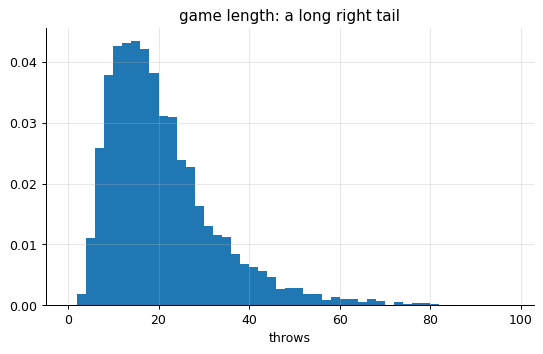

most visited squares (expected visits per game): {34: 2.49, 22: 1.44, 33: 1.42, 32: 1.37, 0: 1.0}


In [3]:
sl = models.snakes_and_ladders()
ab = sl["chain"].absorption()
print(f"expected throws to finish: {ab['expected_steps'][0]:.3f} (sd {np.sqrt(ab['variance_steps'][0]):.2f})")
games = [int(np.argmax(sl["chain"].simulate(500, 0, R(k)) == 36)) for k in range(5000)]
print(f"5000 simulated games: mean {np.mean(games):.3f} +- {np.std(games) / np.sqrt(5000):.3f}")
plt.hist(games, bins=range(0, 100, 2), density=True); plt.xlabel("throws"); plt.title("game length: a long right tail"); plt.show()
vis = ab["N"][0]
top = np.argsort(-vis)[:5]
print("most visited squares (expected visits per game):", {int(ab['transient'][k]): round(float(vis[k]), 2) for k in top})

The board is an absorbing chain with 37 states; one linear solve gives the mean and variance of the game's
length and the expected number of visits to every square - which squares are worth a ladder, which snakes hurt
most - without playing a single game.

## The reflection principle and the ballot theorem

In [4]:
n = 20
for a in (2, 4, 6):
    print(f"P(max of a 20-step walk >= {a}) = {wk.max_distribution(n, a):.5f};  2 P(S_20 >= {a}) - P(S_20 = {a}) = {(2 * sum(wk.paths_count(n, k) for k in range(a, n + 1)) - wk.paths_count(n, a)) / 2**n:.5f}")
walks = wk.simple_walk(n, R(2), n_paths=200_000)
print("simulated P(max >= 4):", np.mean(walks.max(axis=1) >= 4).round(4))
for A, B in ((6, 4), (60, 40), (51, 49)):
    print(f"ballot: A = {A}, B = {B} -> A strictly ahead throughout the count with probability {wk.ballot(A, B):.3f}")

P(max of a 20-step walk >= 2) = 0.66362;  2 P(S_20 >= 2) - P(S_20 = 2) = 0.66362
P(max of a 20-step walk >= 4) = 0.38331;  2 P(S_20 >= 4) - P(S_20 = 4) = 0.38331
P(max of a 20-step walk >= 6) = 0.18925;  2 P(S_20 >= 6) - P(S_20 = 6) = 0.18925


simulated P(max >= 4): 0.3824
ballot: A = 6, B = 4 -> A strictly ahead throughout the count with probability 0.200
ballot: A = 60, B = 40 -> A strictly ahead throughout the count with probability 0.200
ballot: A = 51, B = 49 -> A strictly ahead throughout the count with probability 0.020


Reflecting a path at its first visit to level a maps paths that touch a and end below it one-to-one onto paths
that end above it: P(max ≥ a) = P(S_n ≥ a) + P(S_n > a). The same trick proves the ballot theorem - the winner
of a 51 : 49 vote leads all the way through the count only 2 % of the time - and reappears for Brownian motion
in notebook 15.

## Returns to the origin and the arcsine law

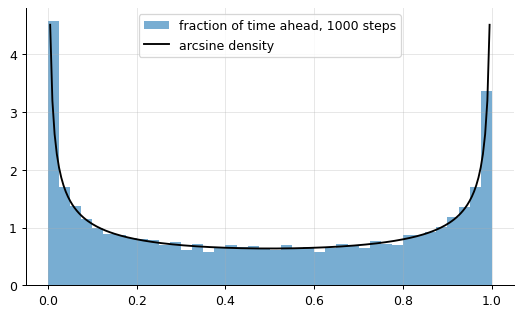

P(ahead less than 10 % of the time) = 0.221 (arcsine law 0.205); P(between 45 % and 55 %) = 0.065
P(first return at step 2n), n = 1, 2, 5: [0.5, 0.125, 0.0273]; they sum to 1 but with infinite mean


In [5]:
w = wk.simple_walk(1000, R(3), n_paths=20_000)
frac_pos = np.mean(w[:, 1:] > 0, axis=1)
x = np.linspace(0, 1, 201)
plt.hist(frac_pos, bins=40, density=True, alpha=0.6, label="fraction of time ahead, 1000 steps"); plt.plot(x[1:-1], 1 / (np.pi * np.sqrt(x[1:-1] * (1 - x[1:-1]))), "k", label="arcsine density")
plt.legend(); plt.show()
print(f"P(ahead less than 10 % of the time) = {np.mean(frac_pos <= 0.1):.3f} (arcsine law {wk.arcsine_cdf(0.1):.3f}); P(between 45 % and 55 %) = {np.mean((frac_pos > 0.45) & (frac_pos < 0.55)):.3f}")
print(f"P(first return at step 2n), n = 1, 2, 5: {[round(wk.first_return_probability(k), 4) for k in (1, 2, 5)]}; they sum to 1 but with infinite mean")

In a fair game the leader rarely changes: the fraction of time spent ahead follows the U-shaped arcsine law, so
a 10 % / 90 % split is *more* likely than 50 / 50. The walk returns to 0 with probability one, but the return
time has infinite mean (its tail decays like n^{−3/2}).

## Pólya: recurrence depends on the dimension

In [6]:
rows = []
for d in (1, 2, 3):
    for steps in (100, 1000, 10_000):
        r = wk.return_probability_by(d, steps, 2000, R(10 * d + steps % 7))
        rows.append((d, steps, r["fraction"], r["std_error"]))
print(pd.DataFrame(rows, columns=["dimension", "steps", "fraction returned", "+-"]).to_string(index=False, float_format="%.3f"))
print(f"limits: 1, 1 (slowly, like 1 - pi/log n), and {wk.POLYA_3D:.4f} in three dimensions")

 dimension  steps  fraction returned    +-
         1    100              0.918 0.006
         1   1000              0.978 0.003
         1  10000              0.994 0.002
         2    100              0.578 0.011
         2   1000              0.681 0.010
         2  10000              0.728 0.010
         3    100              0.298 0.010
         3   1000              0.333 0.011
         3  10000              0.333 0.011
limits: 1, 1 (slowly, like 1 - pi/log n), and 0.3405 in three dimensions


"A drunk man will find his way home, but a drunk bird may get lost forever" (Kakutani): the simple walk is
recurrent in one and two dimensions and transient in three or more. In two dimensions the approach to 1 is
logarithmically slow - after 10⁴ steps more than a quarter of the walkers have still not returned - which no finite
simulation could distinguish from transience without the theory.

## Inside the algorithm: ruin probabilities by first-step analysis

In [7]:
N, p = 10, 0.47
A = np.zeros((N + 1, N + 1)); b = np.zeros(N + 1)
A[0, 0] = A[N, N] = 1; b[0] = 1                         # u_0 = 1 (ruined), u_N = 0
for i in range(1, N):
    A[i, i], A[i, i + 1], A[i, i - 1] = 1, -p, -(1 - p)
u = np.linalg.solve(A, b)
print("u_i = p u_{i+1} + q u_{i-1}:", u[1:N].round(4), "\nclosed form:            ", np.array([wk.ruin_probability(i, N, p) for i in range(1, N)]).round(4))

u_i = p u_{i+1} + q u_{i-1}: [0.9451 0.8832 0.8133 0.7346 0.6458 0.5457 0.4328 0.3055 0.1619] 
closed form:             [0.9451 0.8832 0.8133 0.7346 0.6458 0.5457 0.4328 0.3055 0.1619]


## Exercises
1. In snakes and ladders, which single snake would you remove to shorten the expected game the most? Compute the expected game length for each removal.
2. Simulate 10^4 symmetric walks of 10^4 steps and plot the distribution of the time of the last visit to 0 divided by n. Compare with the arcsine law.
3. **Implement it yourself:** count the n-step paths that stay strictly positive after step 0 and end at k by brute-force enumeration for n = 12, and check the ballot-theorem formula (k/n) C(n, (n+k)/2).